In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

import xarray as xr
import geopandas as gpd
from scipy.spatial import cKDTree

from deltalake import DeltaTable
from deltalake.writer import write_deltalake

from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

# Indices dataset for municipalities

In [6]:
gdf_municipalities = gpd.read_parquet('s3://suyana-pricing/colombia/valles/geometries/location_geometries.parquet')

In [29]:
gdf_municipalities = gdf_municipalities.rename(columns={
    'DEPTO': 'departamento',
    'MPIO_CNMBR': 'municipio'
})

In [3]:
df_indices = pd.read_parquet('s3://suyana-pricing/colombia/valles/outputs/hevelma_seguros/UCSB_prcp_window_indices.parquet')

In [32]:
# Join indices to municipality names
df_indices = gdf_municipalities[['location_id', 'departamento', 'municipio']].merge(
    df_indices,
    how = 'right',
    on = ['location_id']
)

# Yields dataset at municipality level

The downloaded version comes at a yearly resolution at the municipality level.

* The period 2007 to 2018 comes from [EVA1](https://www.datos.gov.co/Agricultura-y-Desarrollo-Rural/Evaluaciones-Agropecuarias-Municipales-EVA/2pnw-mmge/about_data)

* The period 2019 to 2024 comes from [EVA2](https://www.datos.gov.co/Agricultura-y-Desarrollo-Rural/Evaluaciones-Agropecuarias-Municipales-EVA-2019-20/uejq-wxrr/about_data)

In [53]:
df_yields = pd.read_parquet('data/yields_municipalities.parquet')

In [54]:
# Select Period A that refers to all crops seeded during the first semester
df_yields_slice = df_yields[~df_yields['yields'].isna()].copy()
df_yields_slice = df_yields_slice[df_yields_slice['period']=='A']

In [55]:
from scipy import stats
def add_linear_detrend(df, group_cols, yield_col='yields', year_col='year', out_col='yields_detrended'):
    """
    For each group defined by group_cols, fit a linear trend on year
    and return residuals. Groups with < 3 valid obs get NaN.
    """
    def _detrend(grp):
        grp = grp.copy()
        valid = grp.dropna(subset=[yield_col])
        if len(valid) < 3:
            grp[out_col] = np.nan
            return grp
        slope, intercept, *_ = stats.linregress(valid[year_col], valid[yield_col])
        grp[out_col] = grp[yield_col] - (slope * grp[year_col] + intercept)
        return grp
    
    return df.groupby(group_cols, group_keys=False).apply(_detrend)

# Step 1: Regional linear detrend (by crop type + semester)
# Pools all municipalities → stable trend estimate from ~100+ obs
df_yields_slice = add_linear_detrend(
    df_yields_slice, 
    group_cols=['desagregacionCultivo', 'period'],
    out_col='yields_detrended'
)

# Step 2: Remove municipality fixed effect from the detrended residuals
# This accounts for persistent local productivity differences (soil, infrastructure)
df_yields_slice['mun_fixed_effect'] = df_yields_slice.groupby(
    ['municipio', 'desagregacionCultivo', 'period']
)['yields_detrended'].transform('mean')

df_yields_slice['yields_detrended_adj'] = df_yields_slice['yields_detrended'] - df_yields_slice['mun_fixed_effect']

/tmp/ipykernel_541353/2572626591.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_cols, group_keys=False).apply(_detrend)


In [56]:
# Keep the existing simple anomaly for comparison
df_yields_slice['mean_yields'] = df_yields_slice.groupby(
    ['departamento', 'municipio', 'desagregacionCultivo', 'period']
)['yields'].transform('mean')
df_yields_slice['desv_yields'] = df_yields_slice['yields'] - df_yields_slice['mean_yields']

# Merging both datasets

In [58]:
df_merge = df_indices.merge(
    df_yields_slice,
    how = 'left',
    left_on = ['departamento', 'municipio', 'window_year'],
    right_on = ['departamento', 'municipio', 'year']
)

In [60]:
var = 'percentile'
df_merge['rank_bin'] = np.where(
    df_merge[var]>=0.92, '1. >= P92',
    np.where(
        (df_merge[var]>=0.30) & (df_merge[var]<=0.70), '2. >= P30 y <= P70',
        np.where(
            df_merge[var]<=0.08, '3. <= P8', '4. OTRO'
        )
    )
)

In [63]:
df_merge.groupby('rank_bin').agg(
    yields_detrended_adj = ('yields_detrended_adj', 'mean')
)    

,yields_detrended_adj
rank_bin,
1. >= P92,0.011387
2. >= P30 y <= P70,0.004580
3. <= P8,-0.119242
4. OTRO,0.018269


Yields here do not appear to be correlated, but that is because the original analysis to find the actual relationship was done using different time windows for the indices (accumulated precipitation)

* For Deficit the relevant time window is April - September (this includes seed, growing and flowering stages)
* For Excess the relevant time window is September (this corresponds to harvest stage)

However, the numbers above are built using the entire timespan of May - September for both deficit and excess. The client feels more comfortable insuring the entire crop cycle for both perils.

To see the full analysis. Please refer to [YIELDS](https://docs.google.com/spreadsheets/d/12e-MKuaNRhBYYtg94Z5bQLHveEeHCJMQ/edit?gid=2010532855#gid=2010532855)

# Index plot

In [70]:
def cumulate_over_window(df_orig, variable, window, time_dim='time'):
    """Cumulate variable daily within a seasonal window. Returns df with
    cum_{variable} column, season and season_year for filtering."""
    df           = df_orig.copy()
    df[time_dim] = pd.to_datetime(df[time_dim])
    month_day    = df[time_dim].dt.strftime('%m-%d')

    start_md, end_md = window[0], window[1]
    start_month, start_day = map(int, start_md.split('-'))
    end_month,   end_day   = map(int, end_md.split('-'))
    crosses_year = (end_month < start_month) or (
        end_month == start_month and end_day < start_day
    )

    if crosses_year:
        df['in_window']      = np.where(
            (month_day >= start_md) | (month_day <= end_md), 1, np.nan
        )
        df['window_year'] = np.where(
            month_day <= end_md,
            df[time_dim].dt.year - 1,
            df[time_dim].dt.year
        )
    else:
        df['in_window']      = np.where(
            (month_day >= start_md) & (month_day <= end_md), 1, np.nan
        )
        df['window_year'] = df[time_dim].dt.year

    df[f'cum_{variable}'] = (
        df.groupby(['window_year', 'in_window'])[variable]
        .cumsum()
        .fillna(0)
    )
    return df


def plot_activation_history(
    df_swc: pd.DataFrame,
    df_payouts: pd.DataFrame,
    params_plot: dict,
    params_trigger: dict,
    params_s: dict = {},
):
    """
    Two-panel plot: climatology/anomaly time series (top) and
    daily cumulated index with payout bars per window-year (bottom).

    params_plot keys: id_area, id_name, window, crop, tail,
                      season_name, start_time, variable,
                      clim_variable, anom_variable.
    """
    # ---- unpack params -------------------------------------------------------
    id_location       = params_plot['id_location']
    id_name       = params_plot['id_name']
    window_key    = params_plot['window']
    crop          = params_plot['crop']
    tail          = params_plot['tail']
    season_name   = params_plot['season_name']
    start_time    = pd.to_datetime(params_plot['start_time'])
    variable      = params_plot['variable']
    cum_variable  = params_plot['cum_variable']
    clim_var      = params_plot['clim_variable']
    anom_var      = params_plot['anom_variable']
    location_var  = params_s.get('location_var', 'location_id')

    lapse = params_trigger['windows'][window_key]

    # ---- filter df_swc -------------------------------------------------------
    df_swc = df_swc[df_swc[location_var] == id_location].copy()
    df_swc['time'] = pd.to_datetime(df_swc['time'])
    df_swc = df_swc[df_swc['time'] >= start_time].copy()

    # ---- daily cumulation within window -------------------------------------
    # Keep all rows so zeros outside the window produce the saw-tooth shape.
    # Filtering to in_window only would cause slanted lines between windows.
    df_cum = cumulate_over_window(df_swc, cum_variable, lapse)

    # ---- filter df_payouts ---------------------------------------------------
    df_pay = df_payouts[
        (df_payouts[location_var] == id_location) &
        (df_payouts['window']     == window_key) &
        (df_payouts['crop']       == crop) &
        (df_payouts['tail']       == tail)
    ].copy()
    df_pay['window_year'] = df_pay['window_year'].astype(int)

    # Max perc_payout per window_year (collapse duplicates)
    df_bars = (
        df_pay.groupby('window_year')['perc_payout']
        .max()
        .reset_index()
    )

    # Bar positions and widths from window lapse
    start_month, start_day = map(int, lapse[0].split('-'))
    end_month,   end_day   = map(int, lapse[1].split('-'))
    crosses_year = (end_month < start_month) or (
        end_month == start_month and end_day < start_day
    )
    bar_positions = pd.to_datetime(
        df_bars['window_year'].astype(str) + '-' + lapse[0]
    )
    end_year = df_bars['window_year'] + crosses_year
    bar_ends = pd.to_datetime(end_year.astype(str) + '-' + lapse[1])
    bar_widths = (bar_ends - bar_positions).dt.days

    # ---- colormap for bars ---------------------------------------------------
    cmap_bars = LinearSegmentedColormap.from_list(
        'payout', ['darkgreen', 'gold', 'crimson']
    )
    vmax = df_bars['perc_payout'].max() if df_bars['perc_payout'].max() > 0 else 1
    norm = mcolors.Normalize(vmin=0, vmax=vmax)
    bar_colors = [
        cmap_bars(norm(v)) if v > 0 else mcolors.to_rgba('midnightblue')
        for v in df_bars['perc_payout']
    ]

    # ---- build figure --------------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7))

    # -- top panel: climatology and anomaly ------------------------------------
    ax1.plot(df_swc['time'], df_swc[clim_var], lw=1,
             color='darkgreen', label=f'Climatology ({clim_var})')

    mask_below = df_swc[clim_var] > df_swc[variable]
    mask_above = df_swc[clim_var] <= df_swc[variable]
    ax1.fill_between(df_swc['time'], df_swc[clim_var], df_swc[variable],
                     where=mask_below, interpolate=True,
                     color='darkred', alpha=0.4, label='Below climatology')
    ax1.fill_between(df_swc['time'], df_swc[variable], df_swc[clim_var],
                     where=mask_above, interpolate=True,
                     color='midnightblue', alpha=0.4, label='Above climatology')

    # Shade window periods
    for yr in df_bars['window_year']:
        start = pd.to_datetime(f'{yr}-{lapse[0]}')
        end   = pd.to_datetime(f'{int(yr) + crosses_year}-{lapse[1]}')
        ax1.axvspan(start, end, color='orange', alpha=0.15)

    ax1.set_title('a) Climatology and Anomalies', loc='left', fontsize=10)
    ax1.set_ylabel(variable)
    ax1.legend(loc='upper right', fontsize=8)

    # -- bottom panel: daily cumulation + payout bars -------------------------
    ax2.plot(df_cum['time'], df_cum[f'cum_{cum_variable}'], lw=1,
             color='dimgray', label=f'Cumulated {cum_variable} (in-window)')
    ax2.set_title(
        f'b) Trigger activation history -- {season_name}', loc='left', fontsize=10
    )
    ax2.set_ylabel(f'Cumulated {cum_variable}')

    ax2y = ax2.twinx()
    for pos, width, color, val in zip(
        bar_positions, bar_widths, bar_colors, df_bars['perc_payout']
    ):
        ax2y.bar(
            pos, height=val, width=width,
            align='edge', alpha=0.45, color=color
        )

    ax2y.set_ylim(0, vmax * 1.1)
    ax2y.set_ylabel('Payout fraction', fontsize=9)

    ax2.legend(loc='upper left', fontsize=8)

    # Align x-axis limits across both panels
    xlim = ax1.get_xlim()
    ax2.set_xlim(xlim)

    plt.suptitle(
        f'{id_name} | {season_name} | window {window_key} | {crop} | {tail} tail',
        fontsize=12, y=0.98
    )
    plt.tight_layout()
    plt.close(fig)
    return fig

In [67]:
s3_catalog_path = 's3://suyana-pricing/colombia/valles/outputs/hevelma_seguros/UCSB_prcp_daily_indices/'
df_daily = DeltaTable(s3_catalog_path).to_pandas()

In [71]:
df_payouts = pd.read_parquet('s3://suyana-pricing/colombia/valles/outputs/hevelma_seguros/UCSB_prcp_payouts.parquet')

In [90]:
params_plot = {
  'id_location':   'ID-0196', #ID-0196
  'id_name':       'ID-0196', #ID-0196
  'window':        1,
  'crop':          'all',
  'tail':          'lower',
  'season_name':   '05-01 to 09-30 (deficit)',
  'start_time':    '2003-01-01',
  'variable':      'prcp',
  'clim_variable': 'clim_prcp', #clim_prcp
  'anom_variable': 'anom_prcp', #anom_prcp
  'cum_variable':  'prcp' #prcp
}

In [91]:
params_trigger = {
  'variable': 'prcp', #'neg_anom_swc', #
  'group_cols': ['location_id'],
  'dist': 'gamma', #'t', #
  'start_time': '2002-01-01',
  'windows': {
    1: ['05-20', '09-30'],
  }
}

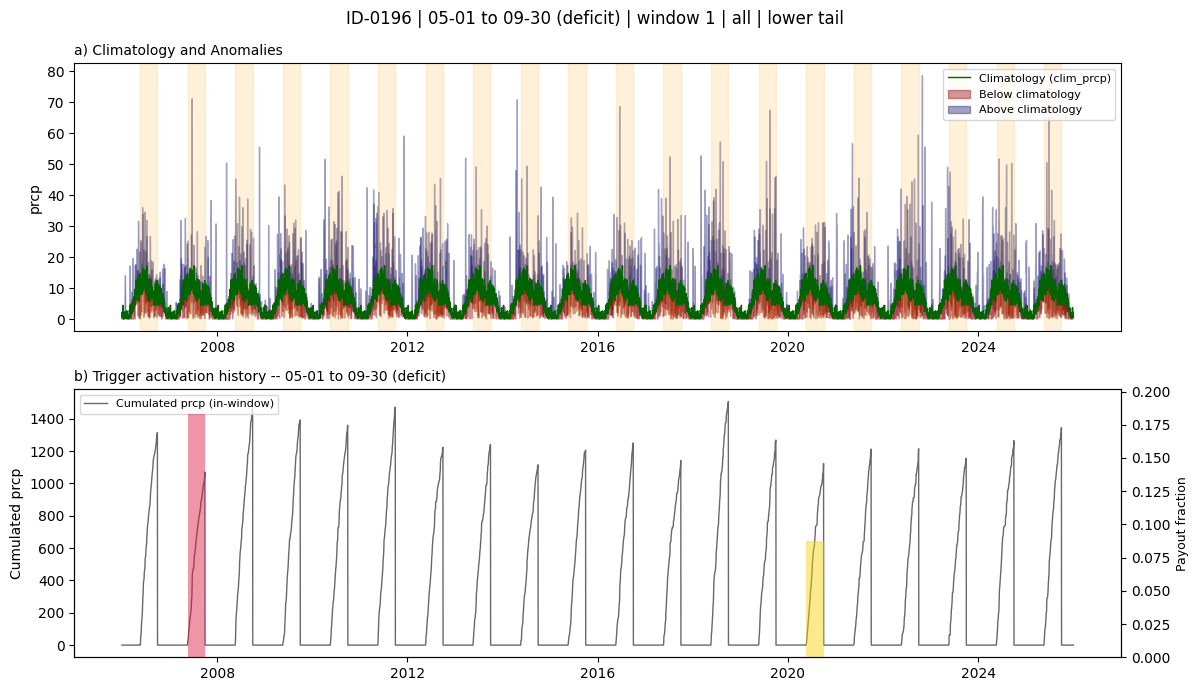

In [92]:
plot_activation_history(df_daily, df_payouts, params_plot, params_trigger)

In [93]:
params_plot['tail'] = 'upper'
params_plot['season_name'] = '05-01 to 09-30 (excess)'

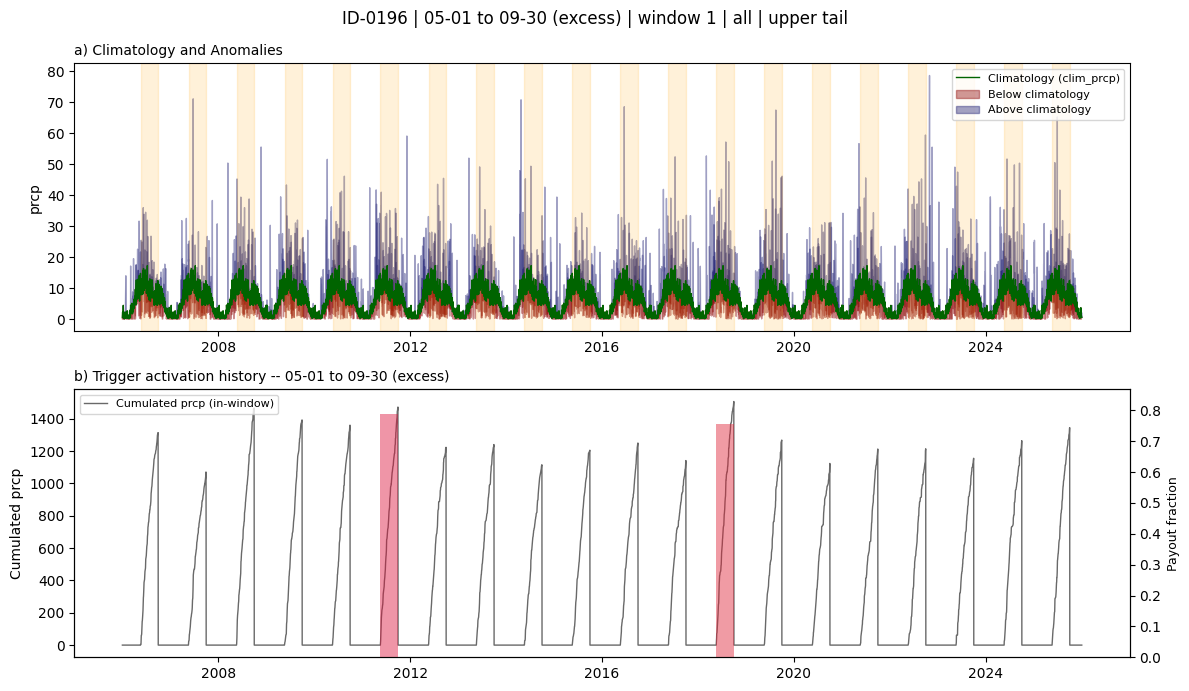

In [94]:
plot_activation_history(df_daily, df_payouts, params_plot, params_trigger)